In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report as cr

In [2]:
df = pd.read_csv('Breast_Cancer.csv')
print(df.head())

   Age   Race Marital Status T Stage  N Stage 6th Stage  \
0   68  White        Married       T1      N1       IIA   
1   50  White        Married       T2      N2      IIIA   
2   58  White       Divorced       T3      N3      IIIC   
3   58  White        Married       T1      N1       IIA   
4   47  White        Married       T2      N1       IIB   

               differentiate Grade   A Stage  Tumor Size Estrogen Status  \
0      Poorly differentiated     3  Regional           4        Positive   
1  Moderately differentiated     2  Regional          35        Positive   
2  Moderately differentiated     2  Regional          63        Positive   
3      Poorly differentiated     3  Regional          18        Positive   
4      Poorly differentiated     3  Regional          41        Positive   

  Progesterone Status  Regional Node Examined  Reginol Node Positive  \
0            Positive                      24                      1   
1            Positive                      1

In [8]:
# Check column names
print("Columns in dataset:", df.columns)

# Assuming the last column is the target and the rest are features
X = df.iloc[:, :-1].values  # Features (all except last column)
y = df.iloc[:, -1].values   # Target (last column)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Columns in dataset: Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')


# CATEGORICAL vlaue to NUMERICAL value

In [6]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

# Convert categorical data to numeric using Label Encoding
label_encoders = {}
for col in categorical_cols:
    label_encoders[col] = LabelEncoder()
    df[col] = label_encoders[col].fit_transform(df[col])

# Display dataset after encoding
print(df.head())

Categorical Columns: Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status', 'Status'],
      dtype='object')
   Age  Race  Marital Status  T Stage   N Stage  6th Stage  differentiate  \
0   68     2               1         0        0          0              1   
1   50     2               1         1        1          2              0   
2   58     2               0         2        2          4              0   
3   58     2               1         0        0          0              1   
4   47     2               1         1        0          1              1   

   Grade  A Stage  Tumor Size  Estrogen Status  Progesterone Status  \
0      3        1           4                1                    1   
1      2        1          35                1                    1   
2      2        1          63                1                    1   
3      3        1          18        

In [12]:
# Initialize and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

C:\Users\Aneesh Mada\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
# Generate classification report with precision, recall, F1-score
report = cr(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95       685
           1       0.82      0.45      0.58       120

    accuracy                           0.90       805
   macro avg       0.86      0.72      0.76       805
weighted avg       0.90      0.90      0.89       805



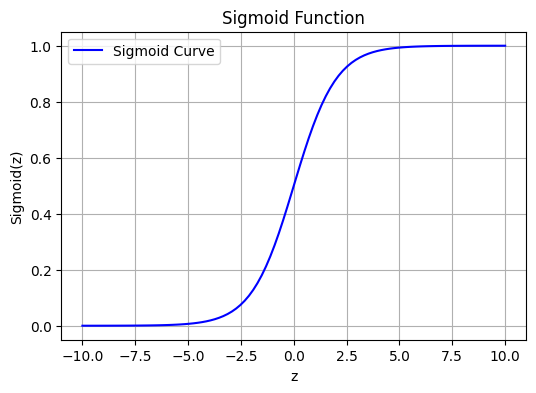

In [13]:
# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate values for visualization
z = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z)

# Plot sigmoid function
plt.figure(figsize=(6, 4))
plt.plot(z, sigmoid_values, label="Sigmoid Curve", color='blue')
plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.legend()
plt.grid()
plt.show()

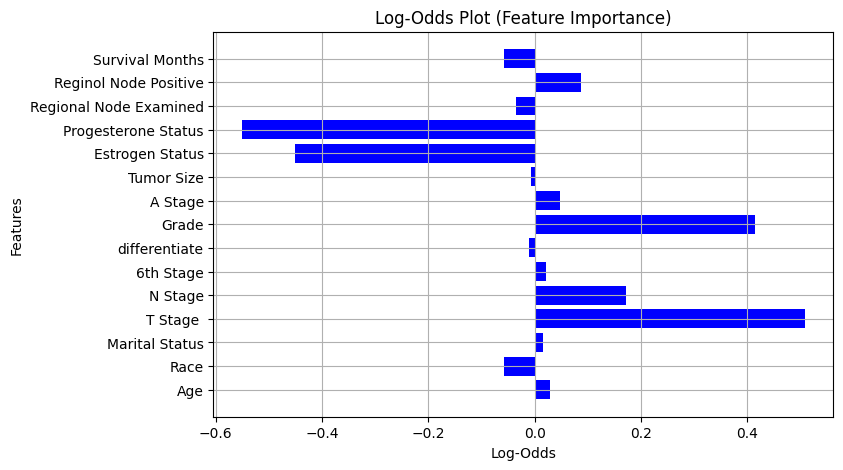

                   Feature  Log-Odds
0                      Age  0.029200
1                     Race -0.058057
2           Marital Status  0.016384
3                 T Stage   0.509086
4                  N Stage  0.171057
5                6th Stage  0.021886
6            differentiate -0.010067
7                    Grade  0.414651
8                  A Stage  0.047753
9               Tumor Size -0.006928
10         Estrogen Status -0.450429
11     Progesterone Status -0.551212
12  Regional Node Examined -0.035795
13   Reginol Node Positive  0.088115
14         Survival Months -0.058166


In [20]:
# Compute log-odds (feature importance)
odds = np.exp(model.coef_)  # Convert coefficients to odds
log_odds = np.log(odds)  # Take log of odds

# If multiple coefficients exist per feature, take the mean
log_odds_mean = np.mean(log_odds, axis=0)

# Get feature names
feature_names = df.columns[:-1]

# Plot log-odds
plt.figure(figsize=(8, 5))
plt.barh(feature_names, log_odds_mean, color='blue')
plt.xlabel("Log-Odds")
plt.ylabel("Features")
plt.title("Log-Odds Plot (Feature Importance)")
plt.grid()
plt.show()

# Display log-odds values
log_odds_df = pd.DataFrame({'Feature': feature_names, 'Log-Odds': log_odds_mean})
print(log_odds_df)
